In [1]:
import hashlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from hydra import compose, initialize_config_dir

cwd = Path.cwd().resolve()
REPO_ROOT = next(
    p for p in (cwd, *cwd.parents)
    if (p / "maps_to_cosmology").is_dir()
)

PACKAGE_DIR = REPO_ROOT / "maps_to_cosmology"
NOTEBOOK_DIR = PACKAGE_DIR / "notebooks"
RUN_DIR = (
    PACKAGE_DIR
    / "results_cosmogrid_baseline_20260813"
    / "seed_42"
)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from maps_to_cosmology.flowmatching import FlowMatching

EVAL_SEED = 42

np.random.seed(EVAL_SEED)
torch.manual_seed(EVAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(EVAL_SEED)

device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")

Initialize the config:

In [2]:
with initialize_config_dir(
    config_dir=str(PACKAGE_DIR / "configs"),
    version_base=None,
):
    cfg = compose(
        config_name="train_flowmatching_cosmogrid_dc2",
        overrides=[
            "seed=42",
            "convergence_maps.split_seed=42",
            "convergence_maps.train_dc2_per_cosmogrid=0",
            "convergence_maps.augment=true",
            "convergence_maps.smoothing_sigma=1.0",
            "encoder.num_bins=4",
            "train.logger.name=results_cosmogrid_baseline",
            "train.logger.version=seed_42",
        ],
    )

assert cfg.seed == 42
assert cfg.convergence_maps.split_seed == 42
assert cfg.convergence_maps.train_dc2_per_cosmogrid == 0
assert cfg.convergence_maps.augment is True
assert float(cfg.convergence_maps.smoothing_sigma) == 1.0
assert cfg.encoder.num_bins == 4

Instantiate the encoder using the checkpoint from a previous training run:

In [3]:
'''
ckpts = [
    "/home/pdailin/blissWL/maps_to_cosmology/results_cosmogrid_ensemble/seed_42/checkpoints/flowmatching_epoch=445.ckpt",
    "/home/pdailin/blissWL/maps_to_cosmology/results_cosmogrid_ensemble/seed_1234/checkpoints/flowmatching_epoch=138.ckpt",
    "/home/pdailin/blissWL/maps_to_cosmology/results_cosmogrid_ensemble/seed_1/checkpoints/flowmatching_epoch=446.ckpt",
]
'''

'\nckpts = [\n    "/home/pdailin/blissWL/maps_to_cosmology/results_cosmogrid_ensemble/seed_42/checkpoints/flowmatching_epoch=445.ckpt",\n    "/home/pdailin/blissWL/maps_to_cosmology/results_cosmogrid_ensemble/seed_1234/checkpoints/flowmatching_epoch=138.ckpt",\n    "/home/pdailin/blissWL/maps_to_cosmology/results_cosmogrid_ensemble/seed_1/checkpoints/flowmatching_epoch=446.ckpt",\n]\n'

In [4]:
ckpts = sorted(
    (RUN_DIR / "checkpoints").glob("*.ckpt")
)

assert len(ckpts) == 1, (
    f"Expected exactly one checkpoint, found: {ckpts}"
)

ckpt_path = ckpts[0]

ckpt_metadata = torch.load(
    ckpt_path,
    map_location="cpu",
    weights_only=False,
)

ckpt_num_bins = int(
    ckpt_metadata["hyper_parameters"]["num_bins"]
)

assert ckpt_num_bins == 4, (
    f"Checkpoint expects {ckpt_num_bins} channels"
)

print("Checkpoint:", ckpt_path)
print("Checkpoint num_bins:", ckpt_num_bins)

del ckpt_metadata

Checkpoint: /home/pdailin/blissWL/maps_to_cosmology/results_cosmogrid_baseline_20260813/seed_42/checkpoints/flowmatching_epoch=295.ckpt
Checkpoint num_bins: 4


Instantiate the test dataloader:

In [5]:
from maps_to_cosmology.datamodule_cosmogrid_dc2 import (
    CosmoGridDC2MapsModule,
)

datamodule = CosmoGridDC2MapsModule(
    cosmogrid_data_dir=cfg.paths.cosmogrid_data_dir,
    dc2_data_dir=cfg.paths.dc2_data_dir,
    train_dc2_per_cosmogrid=(
        cfg.convergence_maps.train_dc2_per_cosmogrid
    ),
    batch_size=cfg.convergence_maps.batch_size,

    num_workers=0,

    val_split=cfg.convergence_maps.val_split,
    test_split=cfg.convergence_maps.test_split,
    standardize_params=(
        cfg.convergence_maps.standardize_params
    ),
    smoothing_sigma=(
        cfg.convergence_maps.smoothing_sigma
    ),
    augment=cfg.convergence_maps.augment,
    seed=cfg.convergence_maps.split_seed,
)

datamodule.setup()

assert len(datamodule.train_dataset) == 7760
assert len(datamodule.val_dataset) == 242
assert len(datamodule.test_dataset) == 242

test_loader = datamodule.test_dataloader()

check_maps, check_params = next(iter(test_loader))

assert check_maps.shape[1:] == (4, 64, 40)
assert check_params.shape[1] == 6
assert torch.isfinite(check_maps).all()
assert torch.isfinite(check_params).all()

print(
    "Dataset sizes:",
    len(datamodule.train_dataset),
    len(datamodule.val_dataset),
    len(datamodule.test_dataset),
)

CosmoGrid train cosmologies: 1940
CosmoGrid train maps: 1940
DC2 train: 0
Train total: 7760
Val: 242 CosmoGrid only
Test: 242 CosmoGrid only
Dataset sizes: 7760 242 242


In [6]:
train_mean = datamodule.param_mean.cpu()
train_std = datamodule.param_std.cpu()

print("train_mean:", train_mean)
print("train_std:", train_std)

train_mean: tensor([ 0.2450,  0.0450,  0.8301,  0.7153,  0.9687, -0.9461])
train_std: tensor([0.0931, 0.0065, 0.2315, 0.0451, 0.0438, 0.2730])


Load in the convergence maps from the test set and evaluate the model on them. Also load the correspoding cosmological parameters from the test set:

In [7]:
num_samples_per_model = 1000

member_samples = []
true_params = None

mean = train_mean.view(1, 1, -1)
std = train_std.view(1, 1, -1)

for model_idx, ckpt in enumerate(ckpts):
    model_seed = EVAL_SEED + model_idx

    torch.manual_seed(model_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(model_seed)

    print(f"Loading {ckpt}")

    model = FlowMatching.load_from_checkpoint(
        ckpt,
        weights_only=False,
        map_location=device,
    )
    model.eval()
    model.to(device)

    assert int(model.hparams.num_bins) == 4

    model_samples = []
    current_true_params = []

    with torch.inference_mode():
        for maps, params_std in test_loader:
            batch_size = maps.shape[0]
            maps = maps.to(device)

            assert maps.shape[1:] == (4, 64, 40)

            x_embedding = model.map_encoder(maps)
            x_expanded = x_embedding.repeat(
                num_samples_per_model,
                1,
            )

            batch_samples_std = model._integrate_ode(
                x_expanded
            )

            batch_samples_std = batch_samples_std.view(
                num_samples_per_model,
                batch_size,
                -1,
            ).cpu()

            batch_samples = (
                batch_samples_std * std + mean
            )

            params_physical = (
                params_std.cpu()
                * train_std.view(1, -1)
                + train_mean.view(1, -1)
            )

            model_samples.append(batch_samples)
            current_true_params.append(params_physical)

    model_samples = torch.cat(
        model_samples,
        dim=1,
    )

    member_samples.append(model_samples)

    if true_params is None:
        true_params = torch.cat(
            current_true_params,
            dim=0,
        )

all_samples = torch.cat(
    member_samples,
    dim=0,
)

posterior_means = all_samples.mean(dim=0)
posterior_stdevs = all_samples.std(
    dim=0,
    unbiased=False,
)

expected_num_samples = (
    len(ckpts) * num_samples_per_model
)

assert all_samples.shape == (
    expected_num_samples,
    242,
    6,
)
assert true_params.shape == (242, 6)
assert torch.isfinite(all_samples).all()
assert torch.isfinite(true_params).all()

print("all_samples:", all_samples.shape)
print("true_params:", true_params.shape)

Loading /home/pdailin/blissWL/maps_to_cosmology/results_cosmogrid_baseline_20260813/seed_42/checkpoints/flowmatching_epoch=295.ckpt


all_samples: torch.Size([1000, 242, 6])
true_params: torch.Size([242, 6])


## ⚠️ Deep Ensemble

The following cell is used to test Deep Ensemble. Use the previous cell if you only need to evaluate one model.

In [8]:
# ckpts = [
#     "/home/xinyangc/blissWL/maps_to_cosmology/results_cosmogrid_4bin_cosmosplit/06-03|16:19:50/checkpoints/flowmatching_cosmogrid_4bin_cosmosplit_epoch=196.ckpt",
#     "/home/xinyangc/blissWL/maps_to_cosmology/results_cosmogrid_4bin_cosmosplit/06-03|16:22:37/checkpoints/flowmatching_cosmogrid_4bin_cosmosplit_epoch=50.ckpt",
#     "/home/xinyangc/blissWL/maps_to_cosmology/results_cosmogrid_4bin_cosmosplit/06-03|16:23:18/checkpoints/flowmatching_cosmogrid_4bin_cosmosplit_epoch=189.ckpt",
# ]

# num_samples = 1000

# ensemble_samples = []
# true_params = None

# mean = train_mean.view(1, 1, -1)
# std = train_std.view(1, 1, -1)

# for ckpt in ckpts:

#     print(f"Loading {ckpt}")

#     model = FlowMatching.load_from_checkpoint(
#         ckpt,
#         weights_only=False,
#         map_location=device,
#     )

#     model.eval()
#     model.to(device)

#     model_samples = []
#     current_true_params = []

#     with torch.no_grad():

#         for maps, params in test_loader:

#             B = maps.shape[0]

#             maps = maps.to(device)

#             x_embedding = model.map_encoder(maps)

#             x_expanded = x_embedding.repeat(num_samples, 1)

#             batch_samples = model._integrate_ode(x_expanded)

#             batch_samples = (
#                 batch_samples
#                 .view(num_samples, B, -1)
#                 .cpu()
#             )

#             batch_samples = batch_samples * std + mean

#             params = (
#                 params.cpu()
#                 * train_std.view(1, -1)
#                 + train_mean.view(1, -1)
#             )

#             model_samples.append(batch_samples)
#             current_true_params.append(params)

#     model_samples = torch.cat(model_samples, dim=1)

#     ensemble_samples.append(model_samples)

#     if true_params is None:
#         true_params = torch.cat(current_true_params, dim=0)

# all_samples = torch.cat(
#     ensemble_samples,
#     dim=0,
# )

# posterior_means = all_samples.mean(dim=0)
# posterior_stdevs = all_samples.std(dim=0)

# print(all_samples.shape)
# print(true_params.shape)

For each of the six cosmological parameters, create a scatterplot of the true parameter value versus the posterior mean. Arrange the six scatterplots in a 2x3 grid.

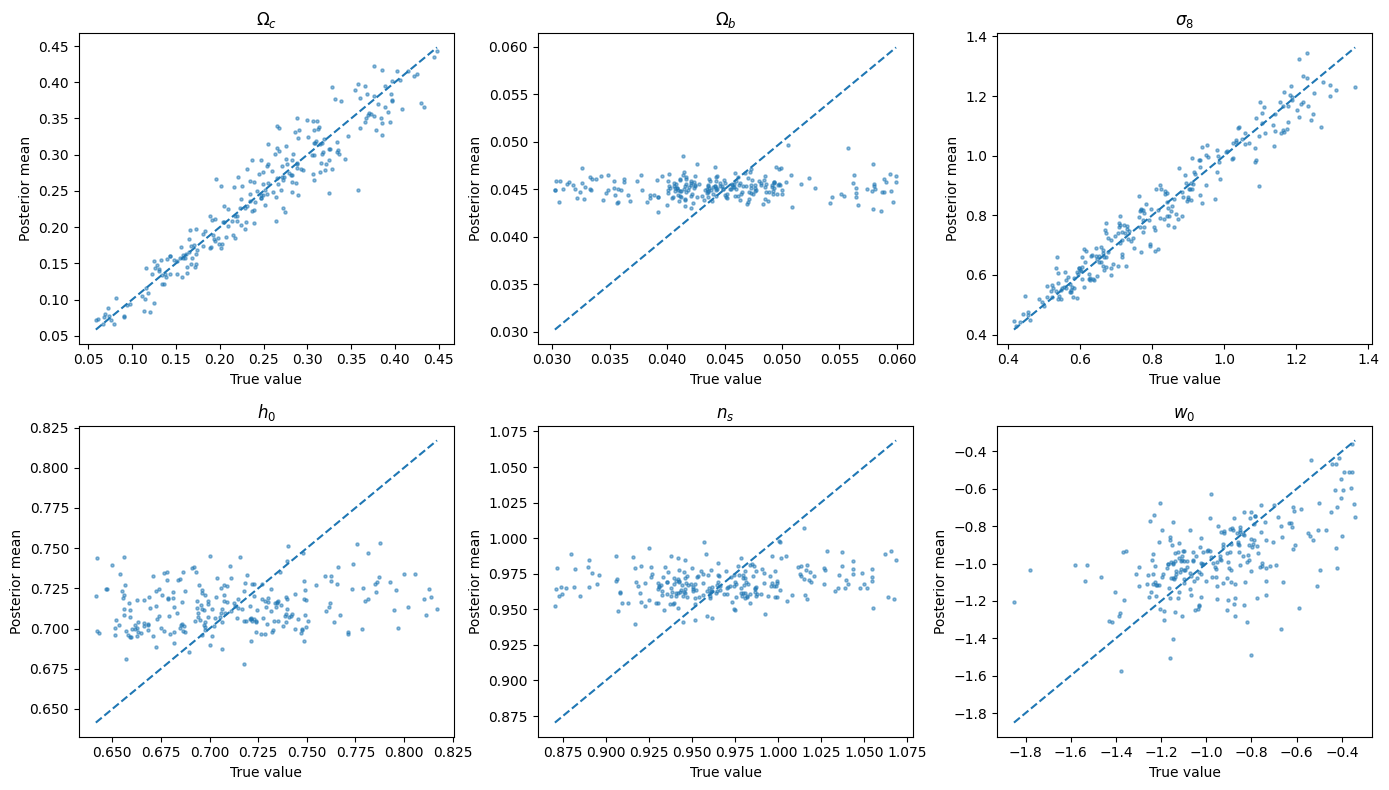

In [9]:
param_names = [
    r"$\Omega_c$", r"$\Omega_b$", r"$\sigma_8$",
    r"$h_0$", r"$n_s$", r"$w_0$"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]

    x = true_params[:, i].numpy()
    y = posterior_means[:, i].numpy()

    ax.scatter(x, y, s=5, alpha=0.5)
    minv = min(x.min(), y.min())
    maxv = max(x.max(), y.max())
    ax.plot([minv, maxv], [minv, maxv], linestyle="--")

    ax.set_xlabel("True value")
    ax.set_ylabel("Posterior mean")
    ax.set_title(param_names[i])

plt.tight_layout()
plt.show()

We load in the real DC2 map used as a reference map:

In [10]:
reference_map = np.load("dc2_stage3_nz_map.npy")[..., :4]
reference_params = torch.tensor(
    [0.22, 0.0448, 0.80, 0.71, 0.963, -1.0]
)

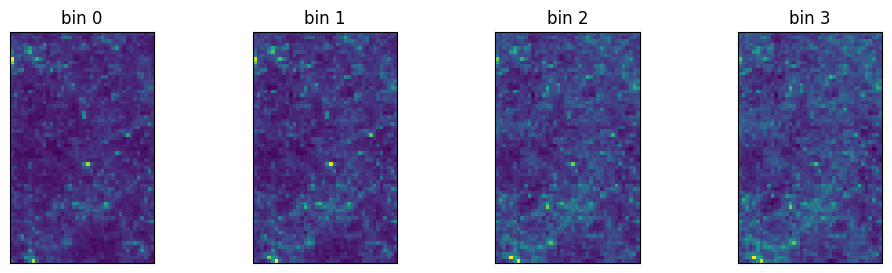

In [11]:
fig, ax = plt.subplots(1, 4, figsize = (12, 3))

for b in range(4):
    _ = ax[b].imshow(reference_map[...,b])
    _ = ax[b].set_title(f"bin {b}")
    _ = ax[b].set_xticks([])
    _ = ax[b].set_yticks([])

We plug this reference map into our trained model and plot the contours of the resulting posterior distributions:

In [12]:
from torchvision.transforms.functional import gaussian_blur

reference_map = np.load(
    "dc2_stage3_nz_map.npy"
)

assert reference_map.shape == (64, 40, 4)
assert np.isfinite(reference_map).all()

reference_map_tensor = (
    torch.from_numpy(reference_map)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float()
)

# Apply exactly the same smoothing used during training.
sigma = cfg.convergence_maps.get(
    "smoothing_sigma",
    None,
)

if sigma is not None:
    sigma = float(sigma)
    kernel_size = 2 * round(2 * sigma) + 1

    reference_map_tensor = gaussian_blur(
        reference_map_tensor,
        kernel_size=[kernel_size, kernel_size],
        sigma=[sigma, sigma],
    )

reference_map_tensor = reference_map_tensor.to(device)

num_samples_per_model = 1000
reference_ensemble_samples = []

for ckpt in ckpts:
    model = FlowMatching.load_from_checkpoint(
        ckpt,
        weights_only=False,
        map_location=device,
    )
    model.eval()
    model.to(device)

    with torch.inference_mode():
        x_embedding = model.map_encoder(
            reference_map_tensor
        )

        x_expanded = x_embedding.repeat(
            num_samples_per_model,
            1,
        )

        samples_std = model._integrate_ode(
            x_expanded
        )

    # Convert to physical parameter space.
    samples = (
        samples_std.cpu()
        * train_std.unsqueeze(0)
        + train_mean.unsqueeze(0)
    )

    reference_ensemble_samples.append(samples)

reference_map_samples = torch.cat(
    reference_ensemble_samples,
    dim=0,
)

print(reference_map_samples.shape)

torch.Size([1000, 6])


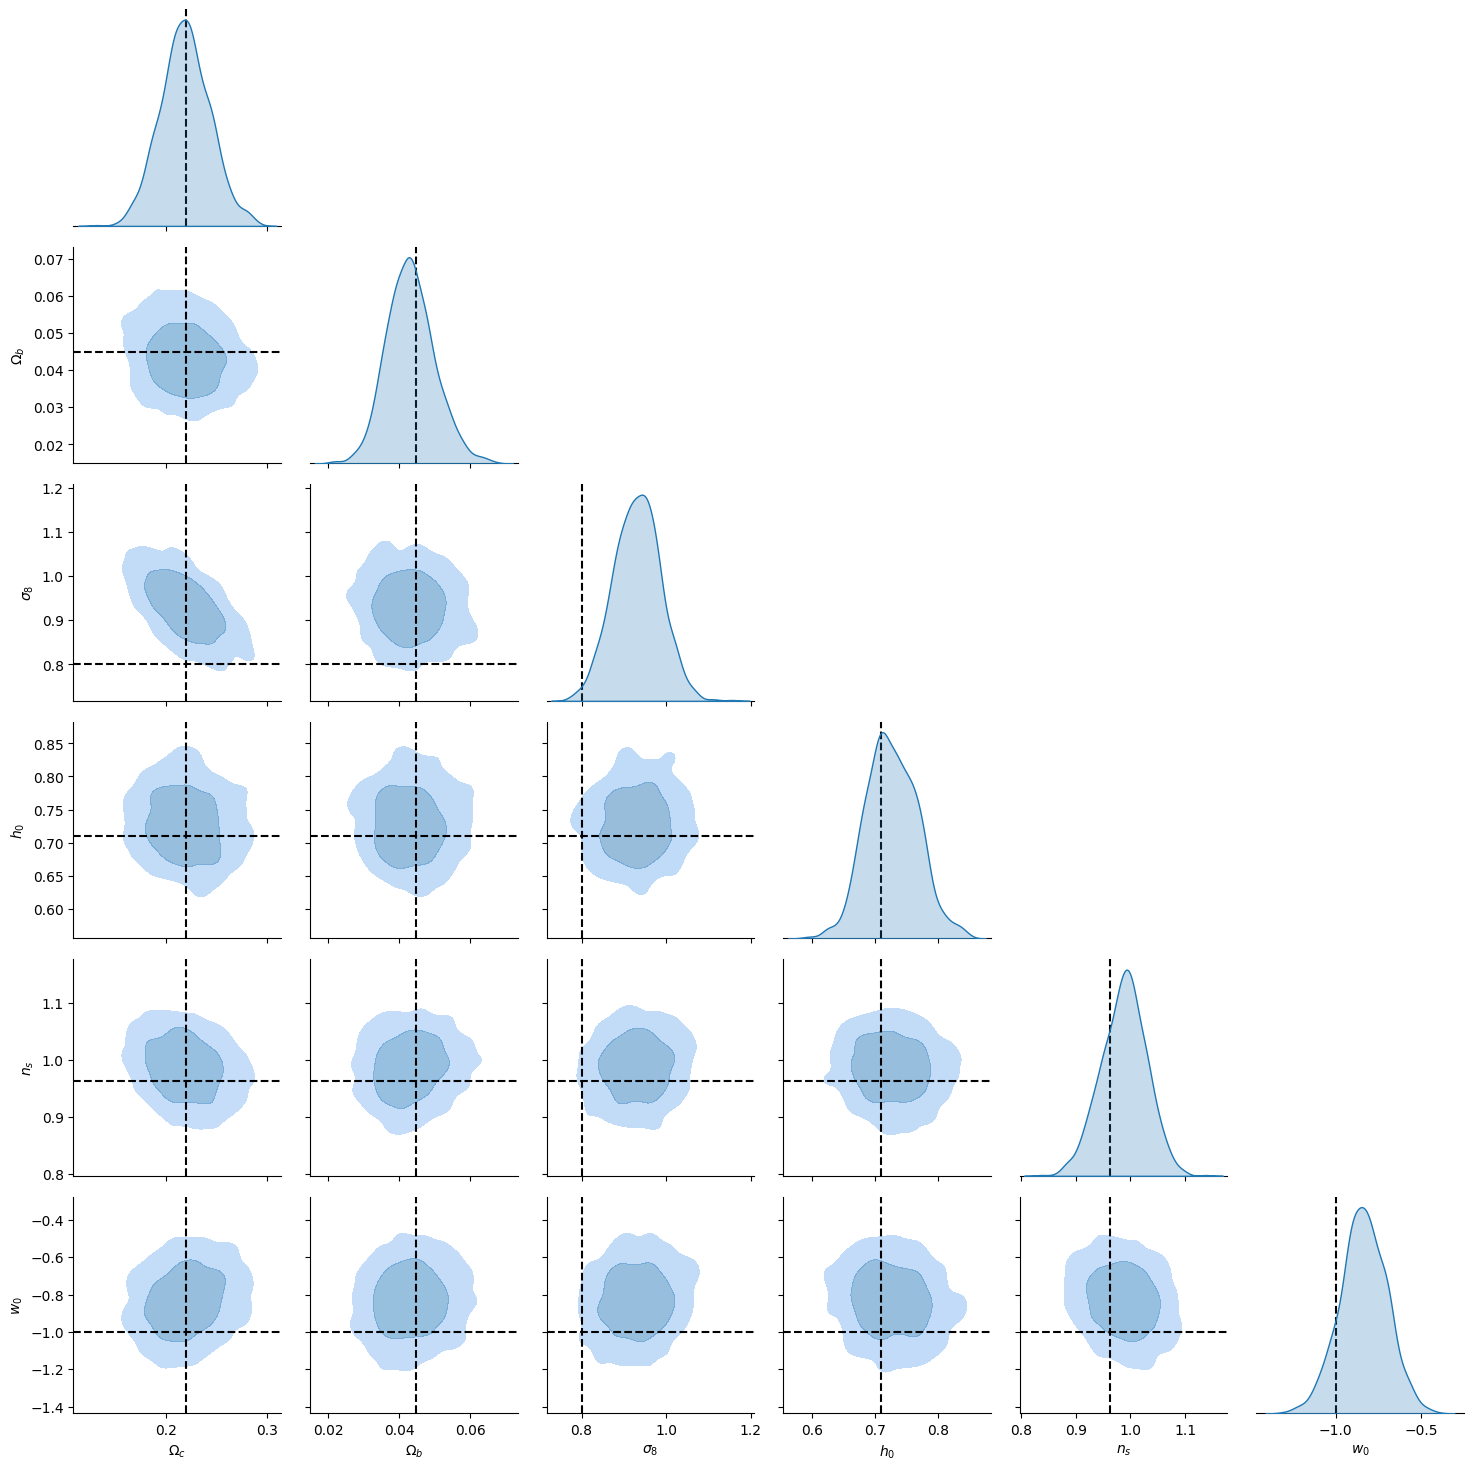

In [13]:
df = pd.DataFrame(
    reference_map_samples.numpy(),
    columns=param_names,
)

true_vals = reference_params.numpy()

g = sns.PairGrid(df, corner=True, diag_sharey=False)
g.map_diag(sns.kdeplot, fill=True)
g.map_lower(sns.kdeplot, levels=[0.05, 0.32, 1.0], fill=True, alpha=0.5)

for i in range(6):
    g.axes[i, i].axvline(
        true_vals[i],
        color="black",
        linestyle="--",
    )

    for j in range(i):
        g.axes[i, j].axvline(
            true_vals[j],
            color="black",
            linestyle="--",
        )
        g.axes[i, j].axhline(
            true_vals[i],
            color="black",
            linestyle="--",
        )

Include light grey dots to show the prior space, i.e. the cosmology parameter set corresponding to the training data:

In [14]:
# Training parameters stored in the dataset are standardized.
train_params_standardized = (
    datamodule.train_dataset.params
    .detach()
    .cpu()
)

train_params_physical = (
    train_params_standardized
    * train_std.unsqueeze(0)
    + train_mean.unsqueeze(0)
)

# Remove the four duplicated parameter copies produced by map augmentation.
train_params_physical = torch.unique(
    train_params_physical,
    dim=0,
)

assert train_params_physical.shape == (1940, 6)
assert torch.isfinite(train_params_physical).all()

training_param_df = pd.DataFrame(
    train_params_physical.numpy(),
    columns=param_names,
)

print(
    "Unique CosmoGrid training cosmologies:",
    len(training_param_df),
)

Unique CosmoGrid training cosmologies: 1940


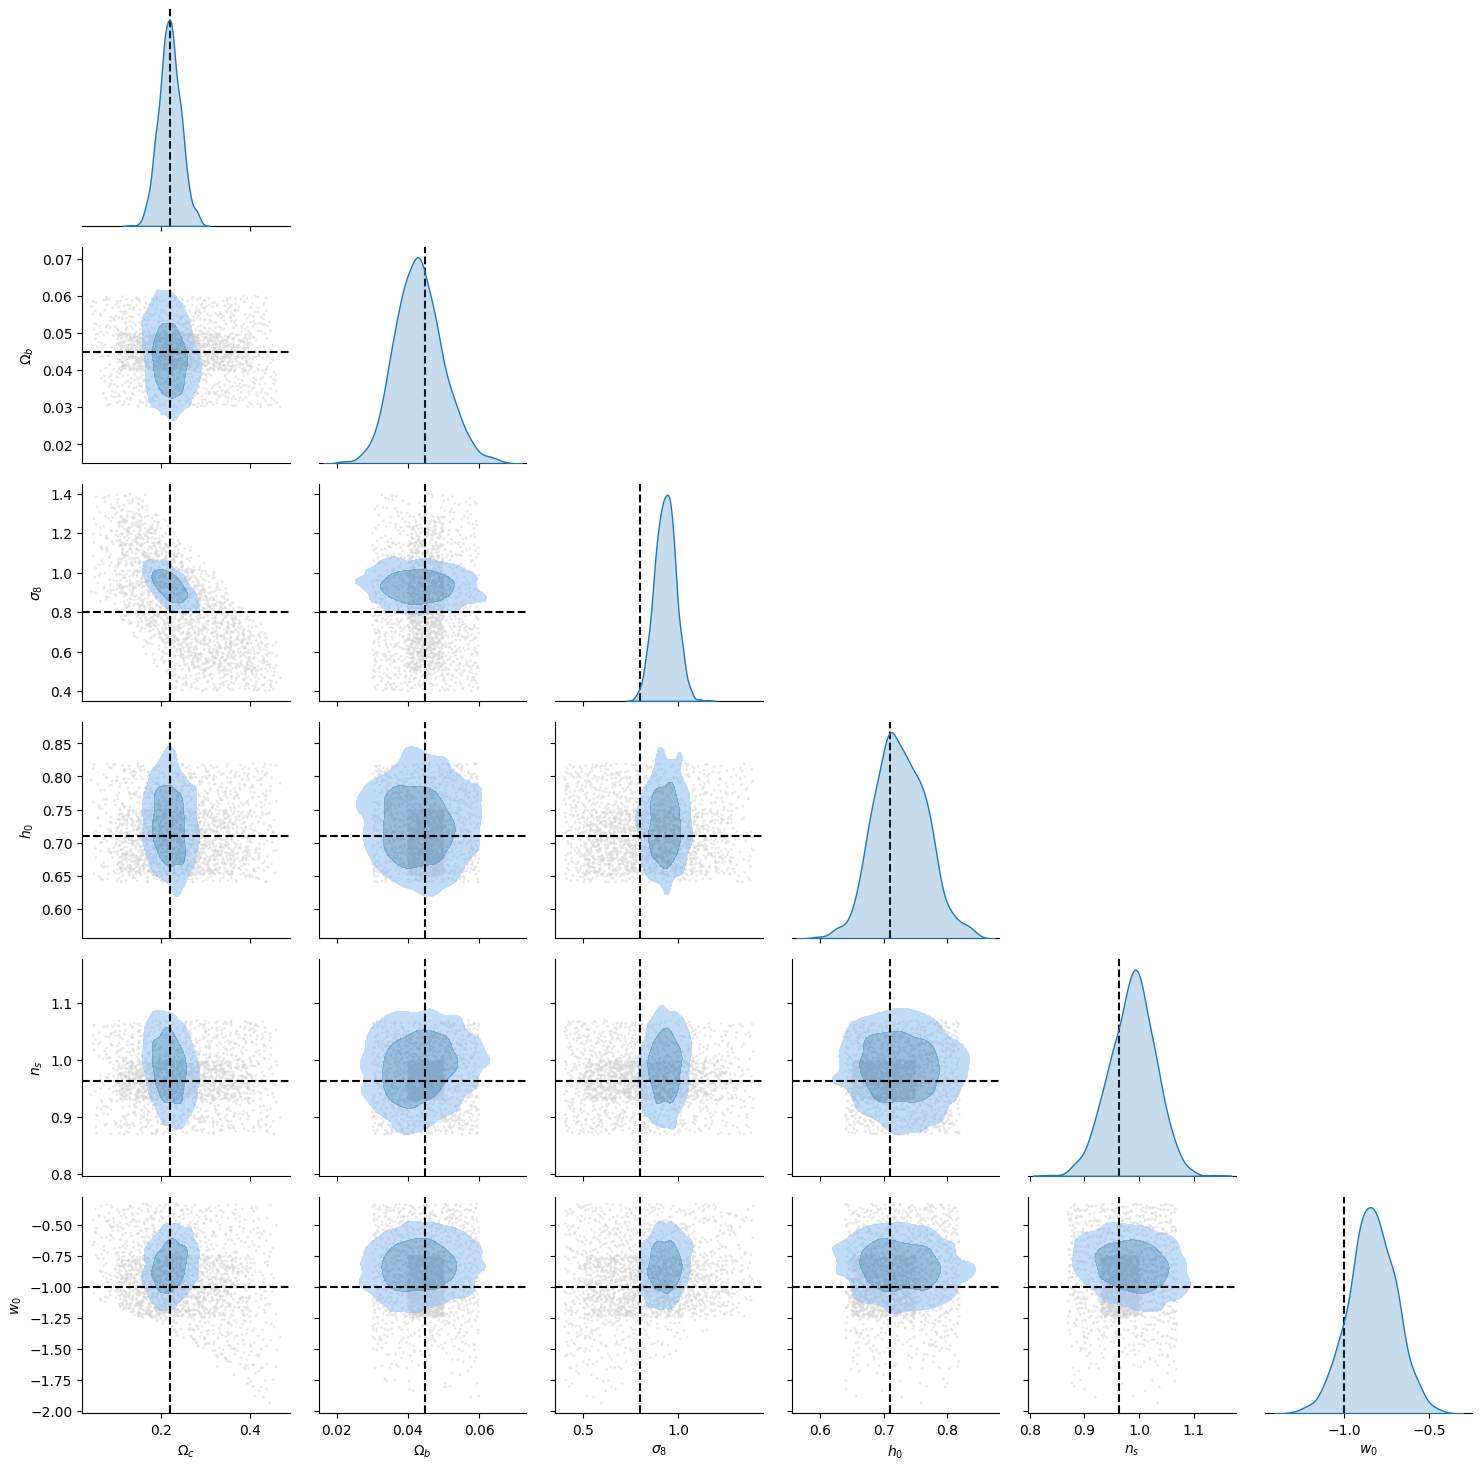

In [15]:
from matplotlib.lines import Line2D

posterior_df = pd.DataFrame(
    reference_map_samples.numpy(),
    columns=param_names,
)

true_vals = reference_params.numpy()

g = sns.PairGrid(
    posterior_df,
    corner=True,
    diag_sharey=False,
)

# Draw training-parameter space first, behind the posterior contours.
for row in range(1, len(param_names)):
    for col in range(row):
        ax = g.axes[row, col]

        ax.scatter(
            training_param_df.iloc[:, col],
            training_param_df.iloc[:, row],
            s=4,
            color="lightgrey",
            alpha=0.5,
            edgecolors="none",
            rasterized=True,
        )

# Posterior marginals and contours.
g.map_diag(
    sns.kdeplot,
    fill=True,
)

g.map_lower(
    sns.kdeplot,
    levels=[0.05, 0.32, 1.0],
    fill=True,
    alpha=0.5,
)

# DC2 truth.
for row in range(len(param_names)):
    g.axes[row, row].axvline(
        true_vals[row],
        color="black",
        linestyle="--",
    )

    for col in range(row):
        ax = g.axes[row, col]

        ax.axvline(
            true_vals[col],
            color="black",
            linestyle="--",
        )

        ax.axhline(
            true_vals[row],
            color="black",
            linestyle="--",
        )

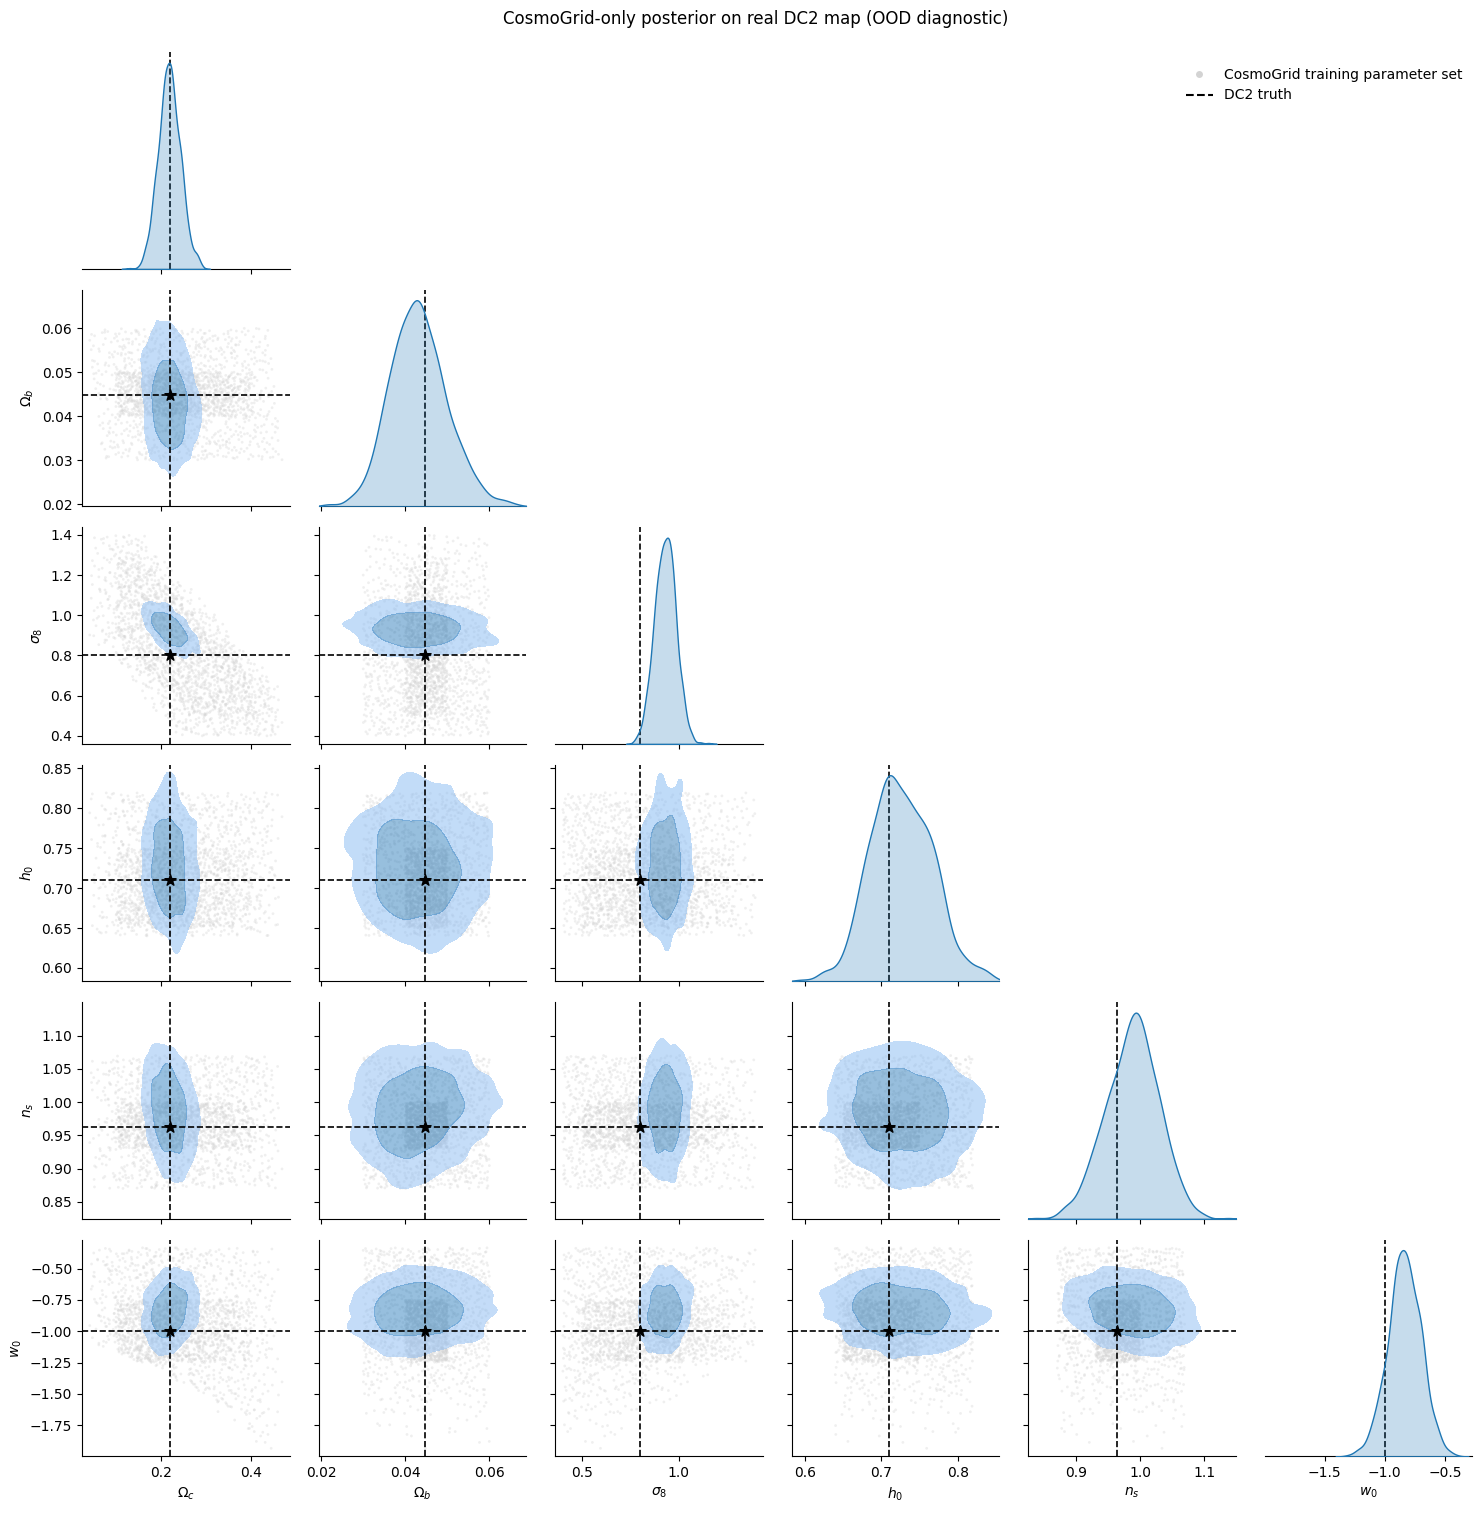

In [16]:
from matplotlib.lines import Line2D

posterior_df = pd.DataFrame(
    reference_map_samples.numpy(),
    columns=param_names,
)

true_vals = reference_params.numpy()

g = sns.PairGrid(
    posterior_df,
    corner=True,
    diag_sharey=False,
    height=2.5,
)

# Draw training-parameter space first, behind the posterior contours.
for row in range(1, len(param_names)):
    for col in range(row):
        ax = g.axes[row, col]

        ax.scatter(
            training_param_df.iloc[:, col],
            training_param_df.iloc[:, row],
            s=4,
            color="lightgrey",
            alpha=0.35,
            edgecolors="none",
            rasterized=True,
            zorder=0,
        )

# Posterior marginals and contours.
g.map_diag(
    sns.kdeplot,
    fill=True,
)

g.map_lower(
    sns.kdeplot,
    levels=[0.05, 0.32, 1.0],
    fill=True,
    alpha=0.5,
    zorder=2,
)

# DC2 truth.
for row in range(len(param_names)):
    g.axes[row, row].axvline(
        true_vals[row],
        color="black",
        linestyle="--",
        linewidth=1.2,
        zorder=4,
    )

    for col in range(row):
        ax = g.axes[row, col]

        ax.axvline(
            true_vals[col],
            color="black",
            linestyle="--",
            linewidth=1.2,
            zorder=4,
        )

        ax.axhline(
            true_vals[row],
            color="black",
            linestyle="--",
            linewidth=1.2,
            zorder=4,
        )

        ax.scatter(
            true_vals[col],
            true_vals[row],
            marker="*",
            s=70,
            color="black",
            zorder=5,
        )

# Ensure the axes include both the training space and posterior.
combined_df = pd.concat(
    [training_param_df, posterior_df],
    ignore_index=True,
)

for parameter_idx, parameter_name in enumerate(param_names):
    values = combined_df[parameter_name].to_numpy()

    lower_limit = values.min()
    upper_limit = values.max()

    span = upper_limit - lower_limit
    padding = 0.04 * span if span > 0 else 0.01

    limits = (
        lower_limit - padding,
        upper_limit + padding,
    )

    # Same x range for every panel in this column.
    for row in range(parameter_idx, len(param_names)):
        ax = g.axes[row, parameter_idx]
        if ax is not None:
            ax.set_xlim(limits)

    # Same y range for every lower-triangle panel in this row.
    for col in range(parameter_idx):
        ax = g.axes[parameter_idx, col]
        if ax is not None:
            ax.set_ylim(limits)

training_handle = Line2D(
    [],
    [],
    marker="o",
    linestyle="none",
    markersize=5,
    markerfacecolor="lightgrey",
    markeredgecolor="none",
    label="CosmoGrid training parameter set",
)

truth_handle = Line2D(
    [],
    [],
    color="black",
    linestyle="--",
    label="DC2 truth",
)

g.figure.legend(
    handles=[training_handle, truth_handle],
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=False,
)

g.figure.suptitle(
    "CosmoGrid-only posterior on real DC2 map (OOD diagnostic)",
    y=1.01,
)

plt.show()

We plug a map from test set into our trained model and plot the contours of the resulting posterior distributions:

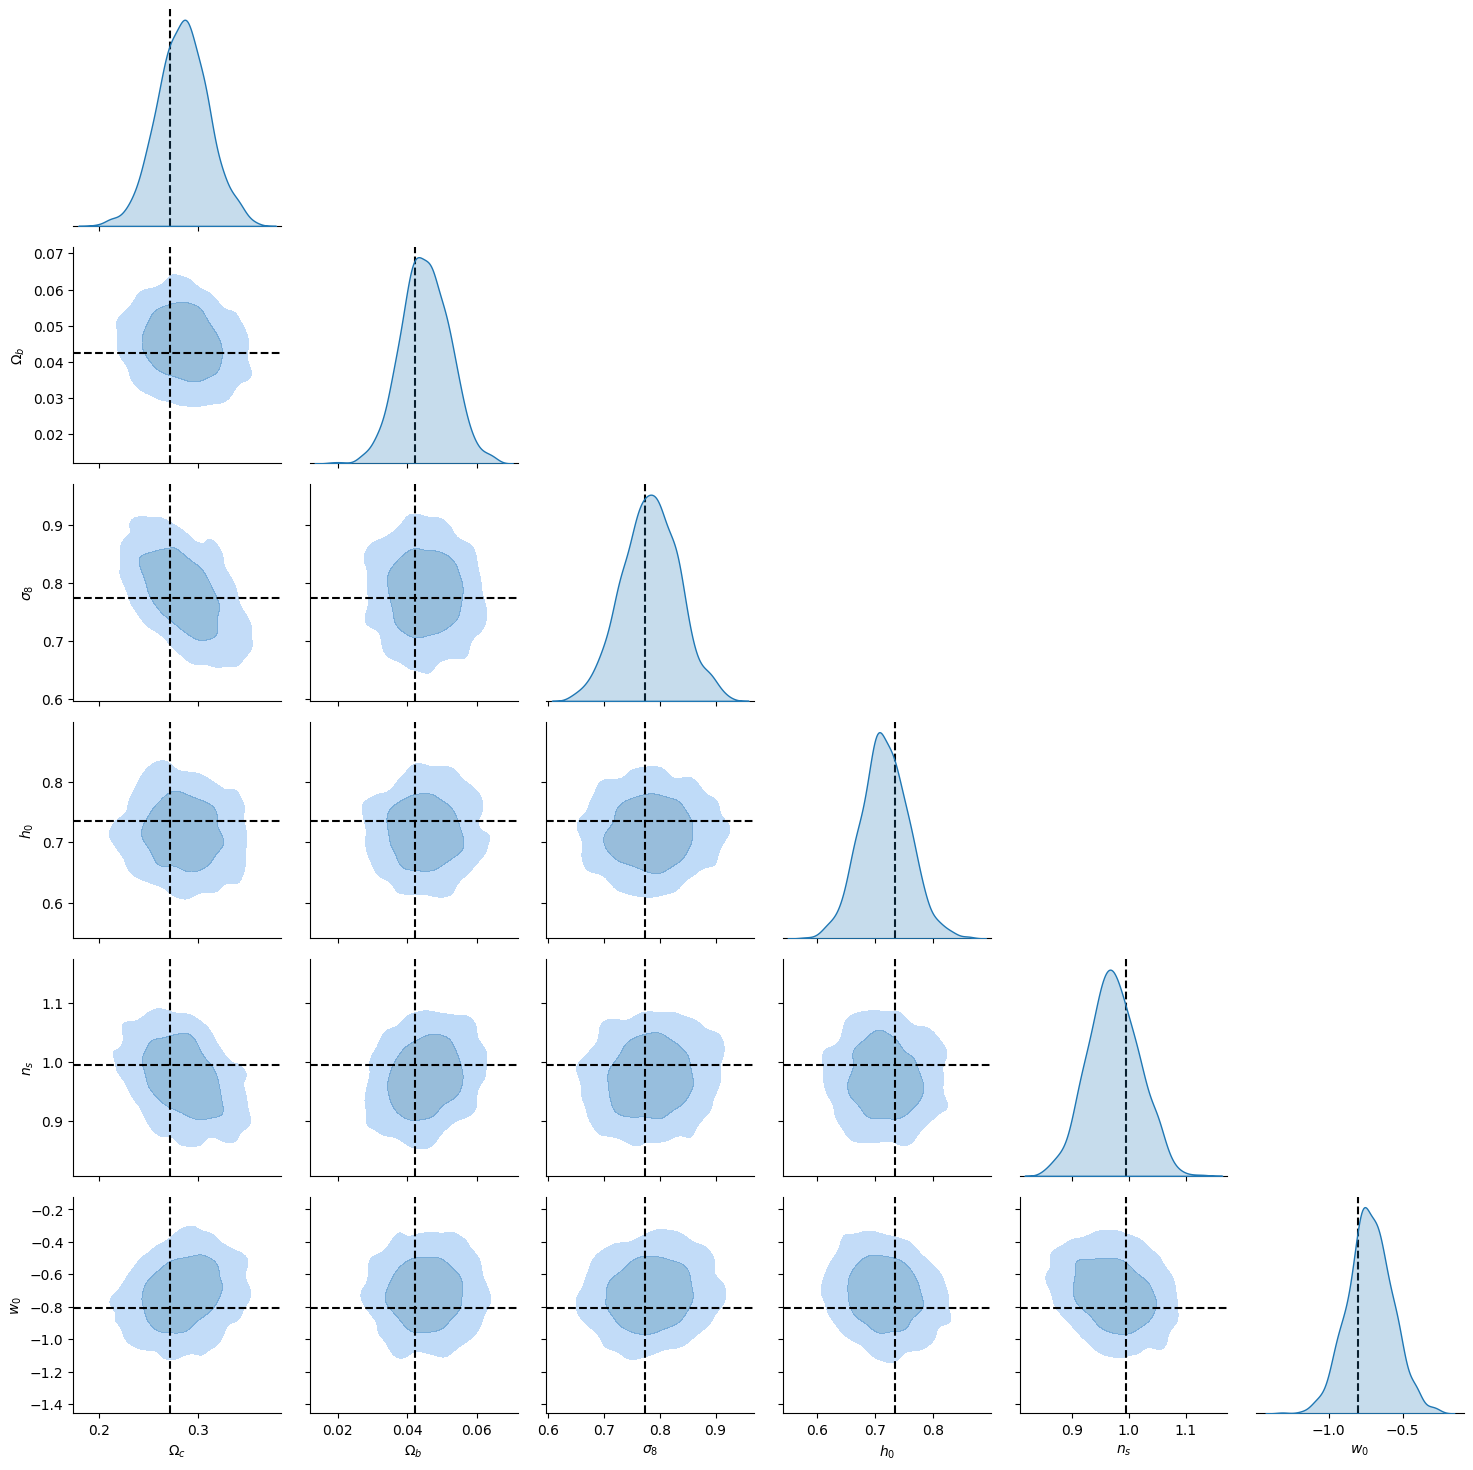

In [17]:
sample_idx = 202
selected_params = true_params[sample_idx]

samples = all_samples[:, sample_idx, :]  # (3000, 6)

posterior_mean = samples.mean(dim=0)
posterior_stdev = samples.std(dim=0)
df = pd.DataFrame(samples.numpy(), columns=param_names)

g = sns.PairGrid(df, corner=True, diag_sharey=False)
g.map_diag(sns.kdeplot, fill=True)
g.map_lower(sns.kdeplot, levels=[0.05, 0.32, 1.0], fill=True, alpha=0.5)

true_vals = selected_params.cpu().numpy()

for i in range(6):
    g.axes[i, i].axvline(true_vals[i], color="black", linestyle="--")
    for j in range(i):
        g.axes[i, j].axvline(true_vals[j], color="black", linestyle="--")
        g.axes[i, j].axhline(true_vals[i], color="black", linestyle="--")

# g.figure.savefig("figures/contourplot_cosmogrid.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)

# plt.show()

Plot credible intervals:

Credible Interval Level: 90%
$\Omega_c$: Coverage = 0.897
$\Omega_b$: Coverage = 0.826
$\sigma_8$: Coverage = 0.884
$h_0$: Coverage = 0.905
$n_s$: Coverage = 0.872
$w_0$: Coverage = 0.723


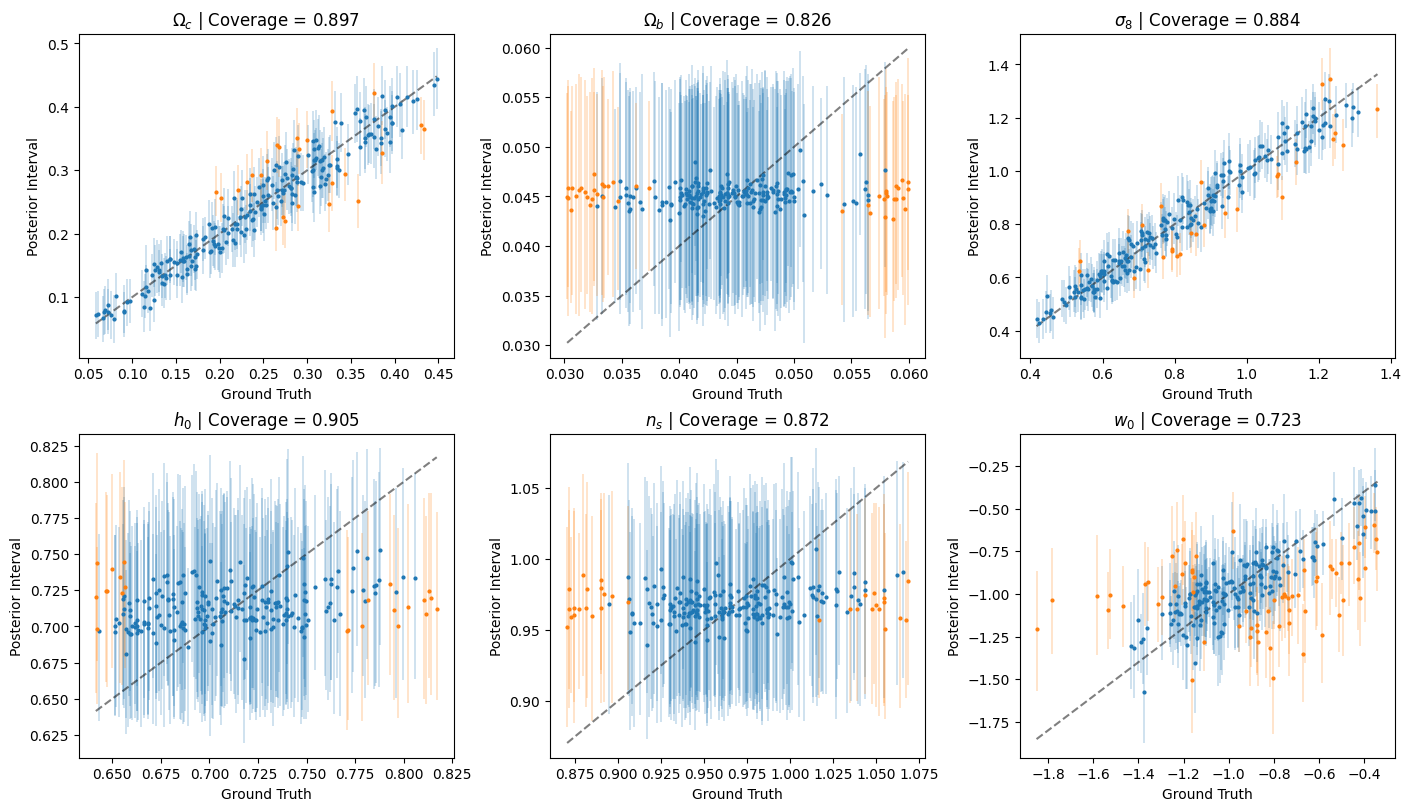

In [18]:
ci_level = 0.90
alpha = 1 - ci_level
lower_q = alpha / 2
upper_q = 1 - alpha / 2

n_plot = 500
rng = np.random.default_rng(42)

mu = all_samples.mean(dim=0).numpy()
lower = torch.quantile(all_samples, lower_q, dim=0).numpy()
upper = torch.quantile(all_samples, upper_q, dim=0).numpy()
true = true_params.numpy()

N = true.shape[0]
idx = rng.choice(N, size=min(n_plot, N), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

print(f"Credible Interval Level: {int(ci_level * 100)}%")
coverages = []

for j, name in enumerate(param_names):
    x = true[idx, j]
    y = mu[idx, j]
    lo = lower[idx, j]
    hi = upper[idx, j]

    covered = (x >= lo) & (x <= hi)
    cov = covered.mean()
    coverages.append(cov)
    print(f"{name}: Coverage = {cov:.3f}")

    ax = axes[j]
    ax.errorbar(
        x[covered],
        y[covered],
        yerr=np.vstack([y[covered] - lo[covered], hi[covered] - y[covered]]),
        fmt="o",
        markersize=2,
        alpha=1,
        linewidth=0.3,
        capsize=0,
    )
    ax.errorbar(
        x[~covered],
        y[~covered],
        yerr=np.vstack([y[~covered] - lo[~covered], hi[~covered] - y[~covered]]),
        fmt="o",
        markersize=2,
        alpha=1,
        linewidth=0.3,
        capsize=0,
    )
    dmin = min(x.min(), y.min())
    dmax = max(x.max(), y.max())
    ax.plot([dmin, dmax], [dmin, dmax], "k--", alpha=0.5)
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Posterior Interval")
    ax.set_title(f"{name} | Coverage = {cov:.3f}")
plt.show()

# fig.savefig("figures/credibleintervals_cosmogrid.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)

Empirical Coverage vs Nominal Coverage

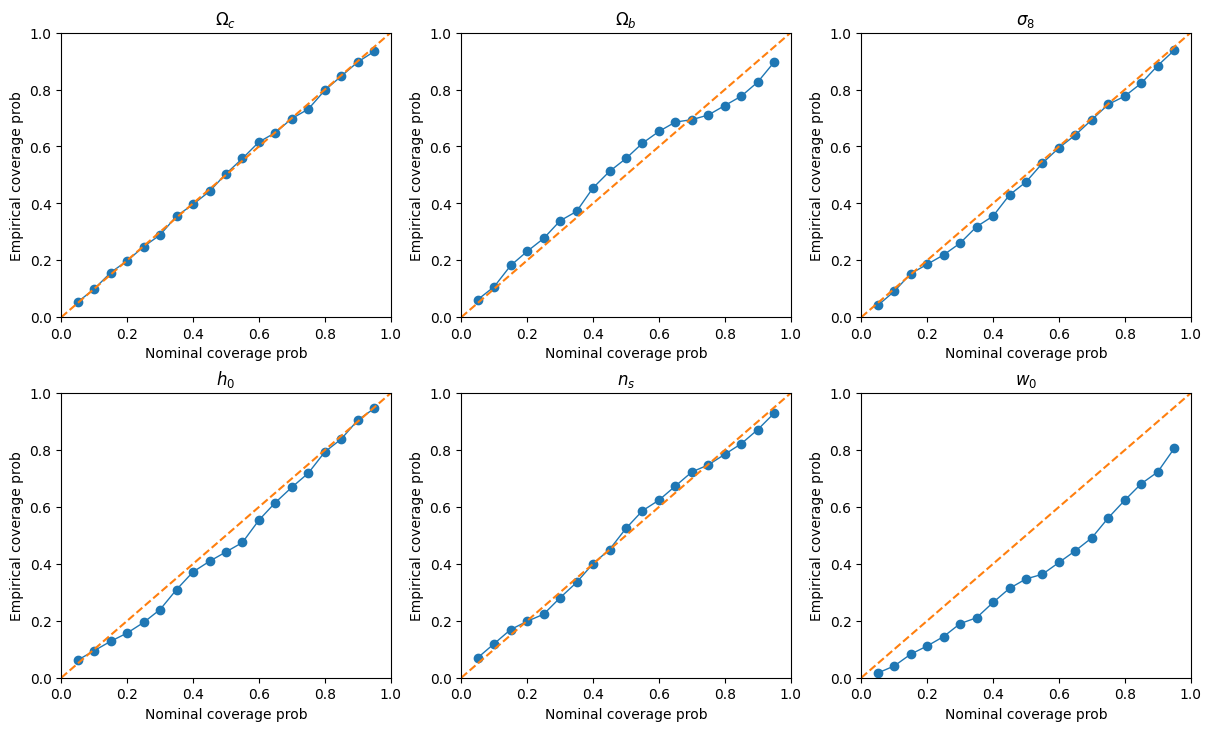

ECE per parameter:
  $\Omega_c$: 0.0061
  $\Omega_b$: 0.0419
  $\sigma_8$: 0.0177
  $h_0$: 0.0320
  $n_s$: 0.0184
  $w_0$: 0.1407


In [19]:
levels = np.linspace(0.05, 0.95, 19)                                                                                                                              
K = len(levels)                                                                                                                                                 
                                                                                                                                                                
y_true = true_params.numpy()                                                                                                                                      
                                                                                                                                                                
N, d = y_true.shape                                       
assert d == len(param_names)

lower_qs = torch.tensor([(1 - c) / 2 for c in levels], dtype=all_samples.dtype)                                                                                                            
upper_qs = torch.tensor([(1 + c) / 2 for c in levels], dtype=all_samples.dtype)
all_lower = torch.quantile(all_samples, lower_qs, dim=0).numpy()  # (K, N_test, 6)                                                                                
all_upper = torch.quantile(all_samples, upper_qs, dim=0).numpy()  # (K, N_test, 6)                                                                                
                                                                                                                                                                
emp = np.zeros((K, d), dtype=float)                                                                                                                               
for k in range(K):                                                                                                                                                
    inside = (y_true >= all_lower[k]) & (y_true <= all_upper[k])
    emp[k] = inside.mean(axis=0)

ncols = 3
nrows = int(np.ceil(d / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.6*nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for j in range(d):
    ax = axes[j]
    ax.plot(levels, emp[:, j], marker="o", linewidth=1)
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(param_names[j])
    ax.set_xlabel("Nominal coverage prob")
    ax.set_ylabel("Empirical coverage prob")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

for j in range(d, len(axes)):
    axes[j].axis("off")

plt.show()
ece = np.mean(np.abs(emp - levels[:, None]), axis=0)
print("ECE per parameter:")
for name, val in zip(param_names, ece):
    print(f"  {name}: {val:.4f}")

# fig.savefig("figures/empirical_cosmogrid.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)

In [20]:
bias = posterior_means - true_params
sigma_width = posterior_stdevs

bias_mean = bias.mean(dim=0).numpy()
bias_abs_mean = bias.abs().mean(dim=0).numpy()
sigma_mean = sigma_width.mean(dim=0).numpy()

summary = pd.DataFrame({
    "param": param_names,
    "mean_bias": bias_mean,
    "mean_abs_bias": bias_abs_mean,
    "mean_1sigma_width": sigma_mean,
})

display(summary)

,param,mean_bias,mean_abs_bias,mean_1sigma_width
0,$\Omega_c$,-0.001215,0.021259,0.025685
1,$\Omega_b$,0.000823,0.005364,0.006531
2,$\sigma_8$,-0.004983,0.043563,0.051733
3,$h_0$,0.001348,0.033554,0.040102
4,$n_s$,0.001899,0.034208,0.041925
5,$w_0$,-0.025414,0.177434,0.140062


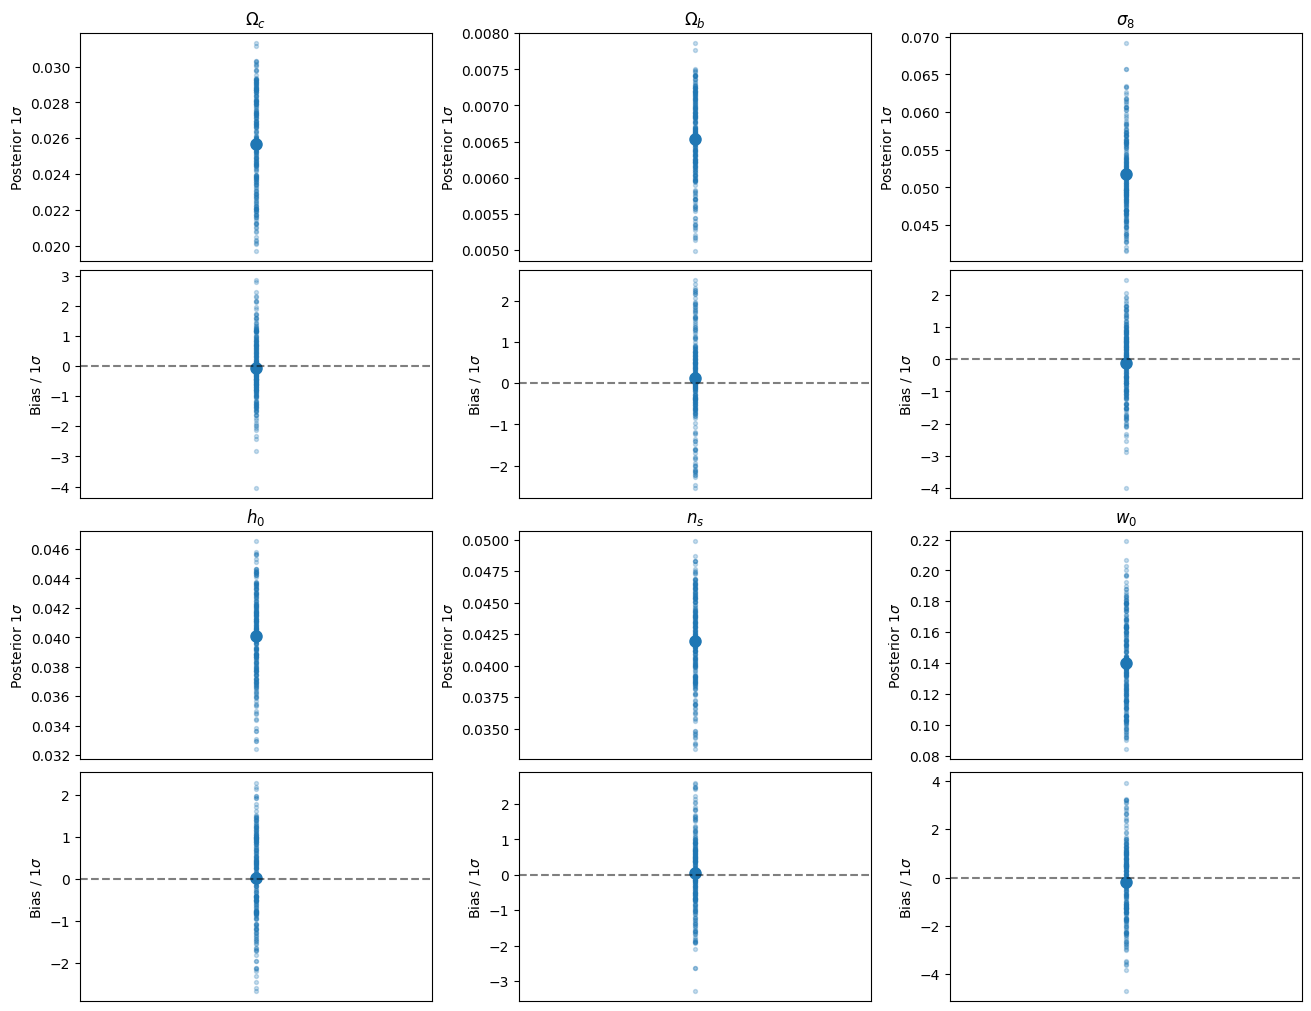

In [21]:
fig, axes = plt.subplots(
    4,
    3,
    figsize=(13, 10),
    constrained_layout=True,
)

rng = np.random.default_rng(42)

for p in range(6):

    col = p % 3
    row_block = 0 if p < 3 else 2

    ax_sigma = axes[row_block, col]
    ax_bias = axes[row_block + 1, col]

    sigma = posterior_stdevs[:, p].cpu().numpy()

    bias = (
        (posterior_means[:, p] - true_params[:, p])
        / posterior_stdevs[:, p]
    ).cpu().numpy()

    idx = rng.choice(
        len(sigma),
        size=min(300, len(sigma)),
        replace=False,
    )

    # -------- 1σ width --------

    ax_sigma.scatter(
        np.zeros(len(idx)),
        sigma[idx],
        s=8,
        alpha=0.25,
        color="tab:blue",
    )

    ax_sigma.plot(
        0,
        sigma.mean(),
        marker="o",
        color="tab:blue",
        markersize=8,
    )

    ax_sigma.set_title(param_names[p])

    ax_sigma.set_ylabel(r"Posterior $1\sigma$")
    ax_sigma.set_xticks([])

    # -------- normalized bias --------

    ax_bias.scatter(
        np.zeros(len(idx)),
        bias[idx],
        s=8,
        alpha=0.25,
        color="tab:blue",
    )

    ax_bias.plot(
        0,
        bias.mean(),
        marker="o",
        color="tab:blue",
        markersize=8,
    )

    ax_bias.axhline(
        0,
        color="black",
        linestyle="--",
        alpha=0.5,
    )

    ax_bias.set_ylabel(r"Bias / $1\sigma$")
    ax_bias.set_xticks([])

plt.show()

# fig.savefig("figures/bias_cosmogrid.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)

S_8 vs. Omega_m plots evaluated on CosmoGrid:

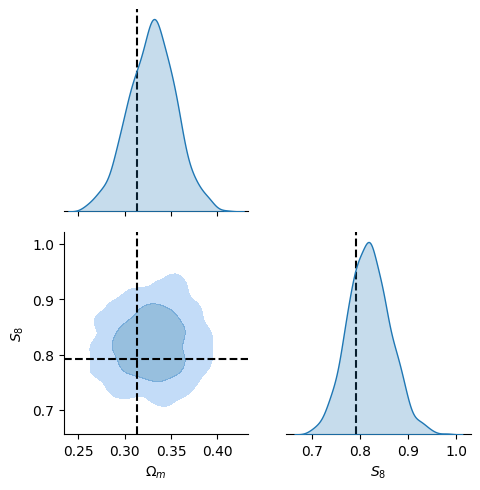

In [22]:
from matplotlib.lines import Line2D

def omega_m_s8(params):
    if isinstance(params, torch.Tensor):
        params = params.detach().cpu().numpy()

    omega_m = params[..., 0] + params[..., 1]   # omega_c + omega_b
    s8 = params[..., 2] * np.sqrt(np.clip(omega_m, 1e-8, None) / 0.3)

    return omega_m, s8


sample_idx = 202  # choose one held-out CosmoGrid map from the test set

posterior = all_samples[:, sample_idx, :]       # ensemble mixture posterior
truth = true_params[sample_idx]

omega_m_samples, s8_samples = omega_m_s8(posterior)
omega_m_true, s8_true = omega_m_s8(truth[None, :])
omega_m_true = omega_m_true.item()
s8_true = s8_true.item()

df_s8 = pd.DataFrame({
    r"$\Omega_m$": omega_m_samples,
    r"$S_8$": s8_samples,
})

g = sns.PairGrid(df_s8, corner=True, diag_sharey=False)
g.map_diag(sns.kdeplot, fill=True)
g.map_lower(
    sns.kdeplot,
    levels=[0.05, 0.32, 1.0],
    fill=True,
    alpha=0.5,
)

ax_om = g.axes[0, 0]
ax_joint = g.axes[1, 0]
ax_s8 = g.axes[1, 1]

ax_om.axvline(omega_m_true, color="black", linestyle="--")
ax_joint.axvline(omega_m_true, color="black", linestyle="--")
ax_joint.axhline(s8_true, color="black", linestyle="--")
ax_s8.axvline(s8_true, color="black", linestyle="--")

### $S_8$–$\Omega_m$ posterior for the real DC2 reference map

`reference_map_samples` and `reference_params` are in physical (de-standardized) parameter space. We use $\Omega_m=\Omega_c+\Omega_b$ and $S_8=\sigma_8\sqrt{\Omega_m/0.3}$.

Because this baseline was trained only on CosmoGrid maps, this is an out-of-distribution diagnostic rather than a calibrated DC2 posterior.

Posterior samples: 1000
DC2 truth: Omega_m=0.2648, S_8=0.7516


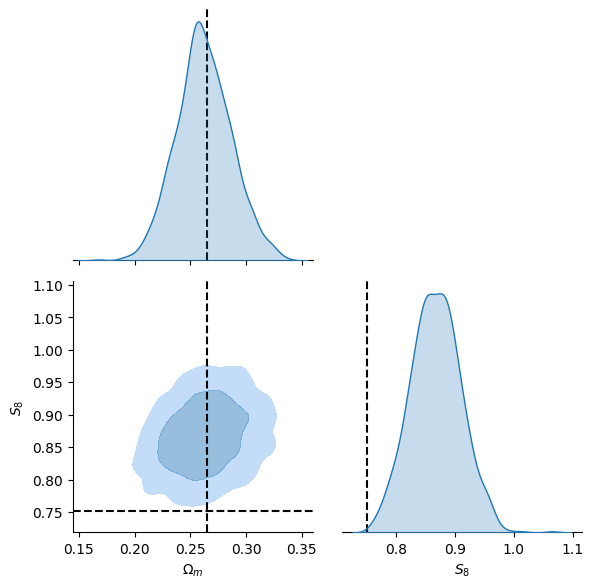

In [23]:
def omega_m_s8(params):
    if isinstance(params, torch.Tensor):
        params = params.detach().cpu().numpy()

    omega_m = params[..., 0] + params[..., 1]  # omega_c + omega_b
    s8 = params[..., 2] * np.sqrt(np.clip(omega_m, 1e-8, None) / 0.3)

    return omega_m, s8


# Physical-space posterior samples produced by the real-DC2 inference cell.
posterior = reference_map_samples.detach().cpu()
assert posterior.ndim == 2 and posterior.shape[-1] == 6
assert torch.isfinite(posterior).all()

omega_m_samples, s8_samples = omega_m_s8(posterior)

reference_params_tensor = reference_params.detach().cpu().to(dtype=posterior.dtype)
assert reference_params_tensor.shape == (6,)
assert torch.isfinite(reference_params_tensor).all()

omega_m_true, s8_true = omega_m_s8(reference_params_tensor[None, :])
omega_m_true = omega_m_true.item()
s8_true = s8_true.item()

df_s8_dc2 = pd.DataFrame({
    r"$\Omega_m$": omega_m_samples,
    r"$S_8$": s8_samples,
})

g = sns.PairGrid(df_s8_dc2, corner=True, diag_sharey=False, height=3.0)
g.map_diag(sns.kdeplot, fill=True)
g.map_lower(
    sns.kdeplot,
    levels=[0.05, 0.32, 1.0],
    fill=True,
    alpha=0.5,
)

ax_om = g.axes[0, 0]
ax_joint = g.axes[1, 0]
ax_s8 = g.axes[1, 1]

ax_om.axvline(omega_m_true, color="black", linestyle="--")
ax_joint.axvline(omega_m_true, color="black", linestyle="--")
ax_joint.axhline(s8_true, color="black", linestyle="--")
ax_s8.axvline(s8_true, color="black", linestyle="--")

print(f"Posterior samples: {posterior.shape[0]}")
print(f"DC2 truth: Omega_m={omega_m_true:.4f}, S_8={s8_true:.4f}")
plt.show()